
# Project walkthrough: RL-to-transformer distillation for a mobile manipulator

This notebook walks through the whole pipeline **up to and including training**,
tab by tab: what the raw data looks like, how it gets turned into the robot's
own point of view, how it's packaged into tagged "entity tokens", how the
transformer model consumes those tokens, and finally a real training loop.

**Not covered here:** running the trained model in the simulator (inference /
rollout evaluation) — that will live in a separate notebook/script.

See `README.md` in the repo root for the written design notes this notebook
is illustrating.



## 1. Setup

Import the project code (everything under `src/`) and a couple of standard
libraries for exploring the data.


In [1]:

import sys, os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from src import schema, transforms, entities
from src.episode import load_episode
from src import EpisodeChunkDataset, EntityTokenizer, ActionChunkTransformer, ModelConfig, masked_mse_loss

DATA_DIR = os.path.join("..", "data")
EXAMPLE_EPISODE = os.path.join(DATA_DIR, "env_000_episode_0008.csv")

torch.manual_seed(0)
np.random.seed(0)
print("ready.")


ready.



## 2. The raw data

Each episode is one CSV recording of the RL policy performing a single
pick-and-place: pick up the cube, carry it to the target, release it. Let's
look at one directly, with no processing at all.


In [2]:

raw_df = pd.read_csv(EXAMPLE_EPISODE)
print(f"episode file: {EXAMPLE_EPISODE}")
print(f"shape: {raw_df.shape[0]} timesteps x {raw_df.shape[1]} columns")
raw_df.head()


episode file: ../data/env_000_episode_0008.csv
shape: 53 timesteps x 48 columns


,sim_time_s,robot_box_x,robot_box_y,robot_box_z,robot_box_quat_w,robot_box_quat_x,robot_box_quat_y,robot_box_quat_z,robot_box_linvel_x,robot_box_linvel_y,...,gripper_actual_pos_rad_gp_rotatingjoint,gripper_actual_vel_rad_s_gp_rotatingjoint,motor_angle_rad_joint1,motor_angle_rad_joint2,motor_angle_rad_joint3,motor_angle_rad_joint4,motor_speed_rad_s_joint1,motor_speed_rad_s_joint2,motor_speed_rad_s_joint3,motor_speed_rad_s_joint4
0,0.000000,0.000000,0.000000,0.0,1.000000,0.0,0.0,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.016667,0.002878,0.002181,0.0,0.999808,0.0,0.0,0.019587,0.240872,0.182409,...,-0.045848,-2.999999,0.000869,0.000796,0.000711,0.000611,0.110942,0.097567,0.083343,0.068239
2,0.033333,0.008961,0.006802,0.0,0.999796,0.0,0.0,0.020197,0.407021,0.315308,...,-0.095888,-3.000002,0.002990,0.002653,0.002277,0.001861,0.164223,0.139769,0.113829,0.086312
3,0.050000,0.018438,0.013856,0.0,0.999986,0.0,0.0,-0.005340,0.635919,0.470865,...,-0.145913,-3.000000,0.006000,0.005163,0.004253,0.003267,0.207325,0.166975,0.124709,0.080446
4,0.066667,0.030743,0.023318,0.0,0.999905,0.0,0.0,-0.013810,0.772418,0.614558,...,-0.116272,2.999999,0.008735,0.007190,0.005533,0.003758,0.152821,0.103052,0.051151,-0.002947


In [3]:

# Every column is a MEASURED state (position/velocity of something), logged
# at every timestep. Nothing here is a "command" -- more on that in section 7.
raw_df.dtypes.to_frame("dtype")


,dtype
sim_time_s,float64
robot_box_x,float64
robot_box_y,float64
robot_box_z,float64
robot_box_quat_w,float64
robot_box_quat_x,float64
robot_box_quat_y,float64
robot_box_quat_z,float64
robot_box_linvel_x,float64
robot_box_linvel_y,float64



## 3. Making sense of the 48 columns: entity groups

The 48 raw columns aren't 48 independent things -- they group into a handful
of physical entities. `src/schema.py` documents this grouping once, so
nothing downstream has to re-derive it from column-name string matching.


In [4]:

groups = {
    "time":               [schema.TIME_COL],
    "base position":       schema.BASE_POS,
    "base orientation":    schema.BASE_QUAT,
    "base lin. velocity":  schema.BASE_LINVEL,
    "base ang. velocity":  schema.BASE_ANGVEL,
    "cube position":       schema.CUBE_POS,
    "cube orientation":    schema.CUBE_QUAT,
    "cube lin. velocity":  schema.CUBE_LINVEL,
    "cube ang. velocity":  schema.CUBE_ANGVEL,
    "target (goal)":       schema.TARGET_POS,
    "gripper-tip position":   schema.ENDPOINT_POS,
    "gripper-tip velocity":   schema.ENDPOINT_LINVEL,
    "gripper open/close":  schema.GRIPPER_GEAR_POS + schema.GRIPPER_GEAR_VEL,
    "wrist roll":          schema.GRIPPER_ROT_POS + schema.GRIPPER_ROT_VEL,
    "arm segment angles":  schema.JOINT_POS,
    "arm segment speeds":  schema.JOINT_VEL,
}
schema_table = pd.DataFrame(
    [(name, len(cols), ", ".join(cols)) for name, cols in groups.items()],
    columns=["group", "n_columns", "columns"],
)
total = schema_table["n_columns"].sum()
print(f"total columns accounted for: {total} (raw file has {raw_df.shape[1]})")
schema_table


total columns accounted for: 48 (raw file has 48)


,group,n_columns,columns
0,time,1,sim_time_s
1,base position,3,"robot_box_x, robot_box_y, robot_box_z"
2,base orientation,4,"robot_box_quat_w, robot_box_quat_x, robot_box_..."
3,base lin. velocity,3,"robot_box_linvel_x, robot_box_linvel_y, robot_..."
4,base ang. velocity,3,"robot_box_angvel_x, robot_box_angvel_y, robot_..."
5,cube position,3,"cube_world_x, cube_world_y, cube_world_z"
6,cube orientation,4,"cube_quat_w, cube_quat_x, cube_quat_y, cube_qu..."
7,cube lin. velocity,3,"cube_linvel_x, cube_linvel_y, cube_linvel_z"
8,cube ang. velocity,3,"cube_angvel_x, cube_angvel_y, cube_angvel_z"
9,target (goal),3,"target_cube_world_x, target_cube_world_y, targ..."



Two groups are degenerate (always zero) across the whole dataset, confirmed
in `scripts/inspect_dataset.py`: `robot_box_z`, `robot_box_quat_x/quat_y`,
and `robot_box_angvel_x/angvel_y`. That's because the base only ever moves
in a flat plane -- x, y, and a single rotation (yaw). Let's confirm that
directly on this episode:


In [5]:

degenerate = schema.DEGENERATE_COLUMNS
raw_df[degenerate].abs().max().to_frame("max abs value over episode (expect 0)")


,max abs value over episode (expect 0)
robot_box_z,0.0
robot_box_quat_x,0.0
robot_box_quat_y,0.0
robot_box_angvel_x,0.0
robot_box_angvel_y,0.0



## 4. What the robot actually looks like

![robot](assets/robot_screenshot.png)

- **Base** (white block): a planar mobile platform. Only x, y, and yaw
  (rotation about the vertical axis) ever change -- confirmed above.
- **Arm** (white ribbed structure): a soft/continuum arm. It *looks* like
  dozens of independent links, but only **4 bend angles** are actually
  commanded (`motor_angle_rad_joint1..4`) -- each one applies uniformly
  across the many physical links belonging to that segment.
- **Gripper** (red, at the tip): 2 controllable DOFs -- an open/close joint
  and a wrist-roll ("rotating") joint.
- **Cube** (red): the object to move, starts in the gray zone.
- **Target**: the green zone -- where the cube needs to end up.



## 5. World frame vs. the robot's own point of view (ego frame)

The base drives continuously throughout the episode -- this is a whole-body
task, not "drive, then reach". Because of that, we don't feed the model raw
room coordinates: we re-express every position **relative to the robot's own
current position and heading**. That's `transforms.world_to_ego` -- a
rotation + shift:

```
relative = point_world - base_pos
x_ego =  cos(yaw)*relative_x + sin(yaw)*relative_y
y_ego = -sin(yaw)*relative_x + cos(yaw)*relative_y
```

Let's load one episode and see both views side by side.


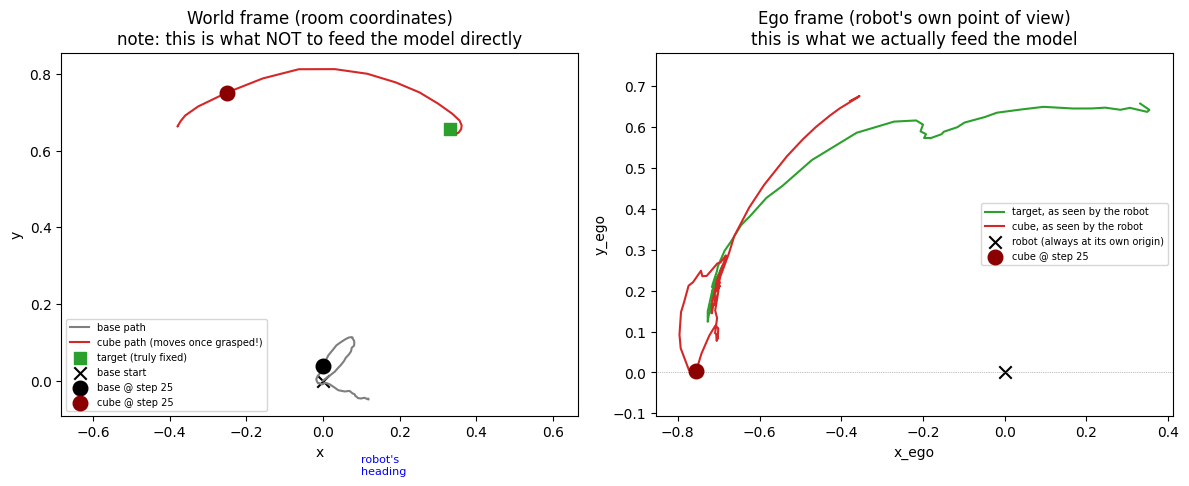

at step 25: cube world y=0.752, base world y=0.039  -- NOT equal, even though cube's y_ego = 0.003 (~0)
base yaw at that step: -70.4 degrees -- the ego axes are ROTATED relative to world axes, not just shifted,
so 'y_ego = 0' means 'directly along the robot's current heading', not 'same world y'.


In [6]:
ep = load_episode(EXAMPLE_EPISODE, action_mode="next_state")

# Highlight one specific timestep on BOTH plots -- the step where the cube's
# ego-frame y crosses ~0 -- to make concretely visible what that actually
# corresponds to in the room.
i_highlight = int(np.argmin(np.abs(ep.cube_pos_ego[:, 1])))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
ax.plot(*ep.base_pos_world.T, label="base path", color="tab:gray")
ax.plot(*ep.cube_pos_world[:, :2].T, label="cube path (moves once grasped!)", color="tab:red")
ax.scatter(*ep.target_pos_world[0, :2], color="tab:green", marker="s", s=80, label="target (truly fixed)")
ax.scatter(*ep.base_pos_world[0], color="black", marker="x", s=80, label="base start")
ax.scatter(*ep.base_pos_world[i_highlight], color="black", s=110, zorder=5,
           label=f"base @ step {i_highlight}")
ax.scatter(*ep.cube_pos_world[i_highlight, :2], color="darkred", s=110, zorder=5,
           label=f"cube @ step {i_highlight}")
yaw = ep.base_yaw[i_highlight]
heading = np.array([np.cos(yaw), np.sin(yaw)]) * 0.3
ax.annotate("", xy=ep.base_pos_world[i_highlight] + heading, xytext=ep.base_pos_world[i_highlight],
            arrowprops=dict(arrowstyle="->", color="blue", lw=2))
ax.text(*(ep.base_pos_world[i_highlight] + heading), "robot's\nheading", color="blue", fontsize=8)
ax.set_title("World frame (room coordinates)\nnote: this is what NOT to feed the model directly")
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.axis("equal"); ax.legend(fontsize=7, loc="best")

ax = axes[1]
ax.plot(*ep.target_pos_ego.T, label="target, as seen by the robot", color="tab:green")
ax.plot(*ep.cube_pos_ego.T, label="cube, as seen by the robot", color="tab:red")
ax.scatter([0], [0], color="black", marker="x", s=80, label="robot (always at its own origin)")
ax.scatter(*ep.cube_pos_ego[i_highlight], color="darkred", s=110, zorder=5,
           label=f"cube @ step {i_highlight}")
ax.axhline(0, color="gray", linewidth=0.5, linestyle=":")
ax.set_title("Ego frame (robot's own point of view)\nthis is what we actually feed the model")
ax.set_xlabel("x_ego"); ax.set_ylabel("y_ego"); ax.axis("equal"); ax.legend(fontsize=7, loc="best")

plt.tight_layout()
plt.show()

print(f"at step {i_highlight}: cube world y={ep.cube_pos_world[i_highlight,1]:.3f}, "
      f"base world y={ep.base_pos_world[i_highlight,1]:.3f}  -- NOT equal, "
      f"even though cube's y_ego = {ep.cube_pos_ego[i_highlight,1]:.3f} (~0)")
print(f"base yaw at that step: {np.degrees(ep.base_yaw[i_highlight]):.1f} degrees "
      f"-- the ego axes are ROTATED relative to world axes, not just shifted,")
print("so 'y_ego = 0' means 'directly along the robot's current heading', not 'same world y'.")



Two things going on in the right-hand plot, worth separating:

- The **target** truly is fixed in the room -- it only appears to move in
  the ego-frame plot because the robot's own position and heading are
  shifting underneath it. That's the intended effect: "the goal is this far
  away, in this direction, right now" is a far easier quantity for the
  model to use than raw room coordinates that mean something different
  every time the base moves.
- The **cube** genuinely moves in the room too, but only *after* it's
  grasped (it gets carried along with the gripper) -- so its path in the
  left-hand world-frame plot is a real trajectory, not a single point.

One more subtlety the highlighted point above makes concrete: `y_ego = 0`
for the cube does **not** mean "the cube's world-y matches the base's
world-y" (see the printed check above -- they're clearly not equal there).
The ego transform *rotates* by the base's heading as well as shifting by
its position, so `y_ego = 0` actually means "the cube currently lies
directly along the direction the robot is facing" -- whatever that
direction happens to be in room coordinates at that moment. The blue arrow
on the left plot shows that heading at the highlighted step; it's turned
well away from the world y-axis, which is exactly why "same world y" and
"y_ego = 0" don't coincide.

At `t=0`, the base is defined to be at the world origin facing angle 0, so
ego-frame and world-frame coincide exactly:



In [7]:

print("target, world frame  (constant):", ep.target_pos_world[0, :2])
print("target, ego frame at t=0:        ", ep.target_pos_ego[0])
print("target, ego frame at final step: ", ep.target_pos_ego[-1], " <- shrinks as the base approaches")


target, world frame  (constant): [0.33144    0.65808082]
target, ego frame at t=0:         [0.33144    0.65808082]
target, ego frame at final step:  [-0.71902245  0.16639128]  <- shrinks as the base approaches



## 6. The wrist-roll joint: why sin/cos instead of raw radians

`gripper_actual_pos_rad_gp_rotatingjoint` behaves like a continuous,
unbounded joint rather than one with a fixed physical range -- across
different episodes it's been seen anywhere from about -1.4 to +1.9 radians,
counting from a per-episode zero. Feeding raw radians risks a
discontinuity: -3.14 and +3.14 point the same physical direction but are
numerically as far apart as possible. Encoding as `(sin, cos)` fixes this --
adjacent angles are always numerically close.


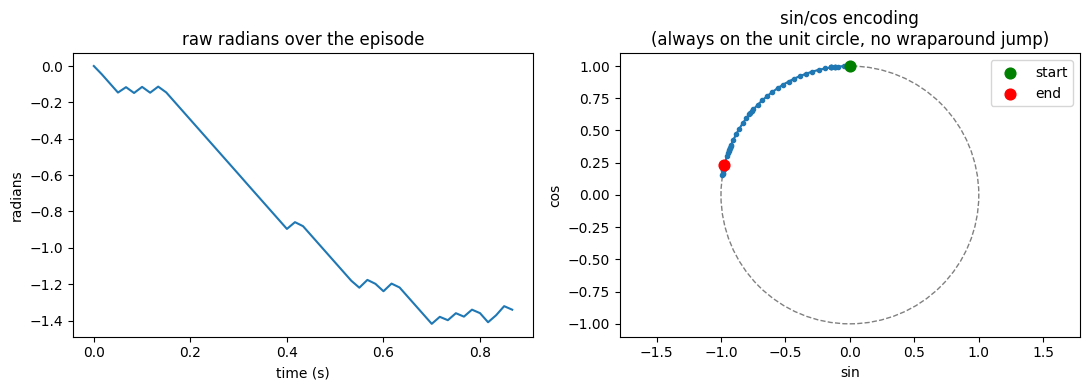

In [8]:

angle = raw_df["gripper_actual_pos_rad_gp_rotatingjoint"].to_numpy()
sc = ep.gripper_rot_sincos

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(ep.t, angle)
axes[0].set_title("raw radians over the episode")
axes[0].set_xlabel("time (s)"); axes[0].set_ylabel("radians")

axes[1].plot(sc[:, 0], sc[:, 1], marker="o", markersize=3)
axes[1].scatter(sc[0, 0], sc[0, 1], color="green", s=60, zorder=5, label="start")
axes[1].scatter(sc[-1, 0], sc[-1, 1], color="red", s=60, zorder=5, label="end")
circle = plt.Circle((0, 0), 1.0, fill=False, linestyle="--", color="gray")
axes[1].add_patch(circle)
axes[1].set_title("sin/cos encoding\n(always on the unit circle, no wraparound jump)")
axes[1].set_xlabel("sin"); axes[1].set_ylabel("cos"); axes[1].axis("equal"); axes[1].legend()
plt.tight_layout(); plt.show()



## 7. The action-labeling problem

Every column in the logs is a **measured state**. Nothing records what the
RL policy actually *commanded* -- there's no `action` or `cmd` column
anywhere. To train by imitation we need an action target for every
timestep, so `src/episode.py` builds one two different ways
(`action_mode`), and we haven't picked a final answer yet:

- **`next_state`** (default): action at time *t* = the controllable state
  observed at *t+1*. Assumes the low-level controller tracks its target
  closely.
- **`finite_diff_vel`**: action at time *t* = `(state[t+1] - state[t]) / dt`,
  or the logged velocity column directly where one exists. No tracking-lag
  assumption, but noisier.

Let's compare them directly on one arm joint:


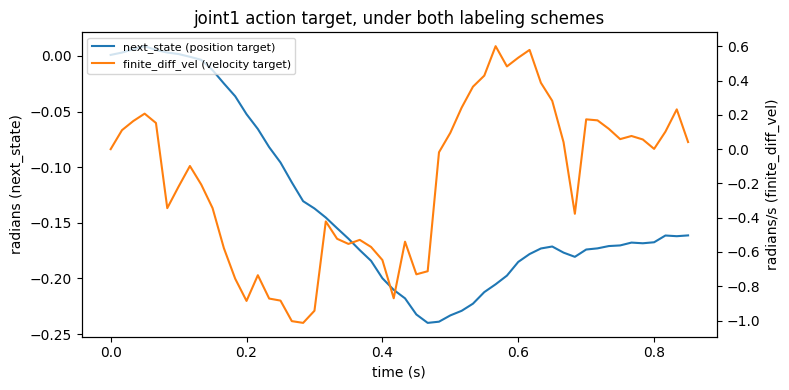

We are training with action_mode='next_state' for the rest of this notebook.


In [9]:

ep_next = load_episode(EXAMPLE_EPISODE, action_mode="next_state")
ep_diff = load_episode(EXAMPLE_EPISODE, action_mode="finite_diff_vel")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(ep_next.t[:-1], ep_next.action_arm_joint[:, 0], label="next_state (position target)")
ax2 = ax.twinx()
ax2.plot(ep_diff.t[:-1], ep_diff.action_arm_joint[:, 0], color="tab:orange", label="finite_diff_vel (velocity target)")
ax.set_xlabel("time (s)"); ax.set_ylabel("radians (next_state)")
ax2.set_ylabel("radians/s (finite_diff_vel)")
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=8)
ax.set_title("joint1 action target, under both labeling schemes")
plt.tight_layout(); plt.show()

print("We are training with action_mode='next_state' for the rest of this notebook.")



## 8. Entity tokens: turning the state into tagged pieces

Instead of one giant flat vector, every "thing in the scene" becomes its own
labeled token: the robot's own body (`proprio`), the cube (`object`), the
goal, and any obstacles (0 today, but the slot is reserved -- see below).

```
token = Linear_kind(raw_features) + type_embedding[TYPE_ID[kind]]
```

`TYPE_ID` is fixed bookkeeping we decide, **not learned**. The content of
each type's tag vector (`type_embedding`) **is** learned, along with the
`Linear_kind` projection weights -- that happens in `EntityTokenizer`
(section 10).


In [10]:

entity_table = pd.DataFrame(
    [(kind, entities.TYPE_ID[kind], dim) for kind, dim in entities.FEATURE_DIM.items()],
    columns=["entity kind", "TYPE_ID", "raw feature dim"],
)
entity_table


,entity kind,TYPE_ID,raw feature dim
0,proprio,0,21
1,object,1,5
2,goal,2,3
3,obstacle,3,3


In [11]:

i = 20  # an arbitrary timestep mid-episode
print("proprio features (robot's own body), shape", entities.proprio_features(ep, i).shape)
print(np.round(entities.proprio_features(ep, i), 3))
print()
print("object features (the cube), shape", entities.object_features(ep, i).shape)
print(np.round(entities.object_features(ep, i), 3), " <- [x_ego, y_ego, z, vx_ego, vy_ego]")
print()
print("goal features (the target), shape", entities.goal_features(ep, i).shape)
print(np.round(entities.goal_features(ep, i), 3), " <- [x_ego, y_ego, z]")
print()
print("obstacle features, shape", entities.obstacle_features(ep, i).shape, "<- zero rows: no obstacle data exists yet")


proprio features (robot's own body), shape (21,)
[-0.145 -0.153 -0.16  -0.166 -0.523 -0.444 -0.35  -0.243 -0.58   3.
 -0.641  0.767 -3.    -0.148 -0.792 -2.53  -0.715  0.077  0.422 -0.016
 -0.792]

object features (the cube), shape (5,)
[-0.702  0.083  0.42  -0.133 -0.82 ]  <- [x_ego, y_ego, z, vx_ego, vy_ego]

goal features (the target), shape (3,)
[-0.206  0.59   0.42 ]  <- [x_ego, y_ego, z]

obstacle features, shape (0, 3) <- zero rows: no obstacle data exists yet



## 9. Packaging episodes into training samples: `EpisodeChunkDataset`

Each training sample is: one timestep's entity features, paired with a
**chunk** of the next `chunk_size` pseudo-actions (not just the single next
action -- predicting a short sequence at once reduces compounding error at
rollout time). Episode-end padding is masked out rather than dropped, so
every timestep of every episode is usable as a starting point.


In [12]:

ds = EpisodeChunkDataset(DATA_DIR, chunk_size=12, history=0, max_obstacles=8, action_mode="next_state")
print(f"{len(ds.episodes)} episodes -> {len(ds)} (timestep, chunk) training samples")

sample = ds[0]
shape_table = pd.DataFrame(
    [(k, tuple(v.shape), str(v.dtype)) for k, v in sample.items() if hasattr(v, "shape")],
    columns=["field", "shape", "dtype"],
)
shape_table


298 episodes -> 15919 (timestep, chunk) training samples


,field,shape,dtype
0,proprio,"(1, 21)",torch.float32
1,object,"(1, 5)",torch.float32
2,goal,"(1, 3)",torch.float32
3,obstacles,"(1, 8, 3)",torch.float32
4,obstacle_mask,"(1, 8)",torch.float32
5,action_chunk,"(12, 10)",torch.float32
6,action_mask,"(12,)",torch.float32


In [13]:

from torch.utils.data import DataLoader
dl = DataLoader(ds, batch_size=8, shuffle=True)
batch = next(iter(dl))
pd.DataFrame(
    [(k, tuple(v.shape)) for k, v in batch.items() if hasattr(v, "shape")],
    columns=["field", "batch shape (batch dim first)"],
)


,field,batch shape (batch dim first)
0,proprio,"(8, 1, 21)"
1,object,"(8, 1, 5)"
2,goal,"(8, 1, 3)"
3,obstacles,"(8, 1, 8, 3)"
4,obstacle_mask,"(8, 1, 8)"
5,action_chunk,"(8, 12, 10)"
6,action_mask,"(8, 12)"
7,step,"(8,)"



## 10. `EntityTokenizer`: features -> tagged tokens

Runs the batch above through the actual tokenizer module (untrained --
freshly initialized, so the numbers themselves aren't meaningful yet, only
the *shapes* and the *masking* matter here).


In [14]:

tok = EntityTokenizer(d_model=128)
tokens, mask = tok(
    proprio=batch["proprio"][:, -1],
    obj=batch["object"][:, -1],
    goal=batch["goal"][:, -1],
    obstacles=batch["obstacles"][:, -1],
    obstacle_mask=batch["obstacle_mask"][:, -1],
)
print("tokens:", tuple(tokens.shape), " <- (batch, 3 fixed entities + max_obstacles, d_model)")
print("mask:  ", tuple(mask.shape))
print("mask, first sample:", mask[0].tolist(), " <- [proprio, object, goal] always 1, obstacle slots all 0 (none exist)")


tokens: (8, 11, 128)  <- (batch, 3 fixed entities + max_obstacles, d_model)
mask:   (8, 11)
mask, first sample: [1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]  <- [proprio, object, goal] always 1, obstacle slots all 0 (none exist)


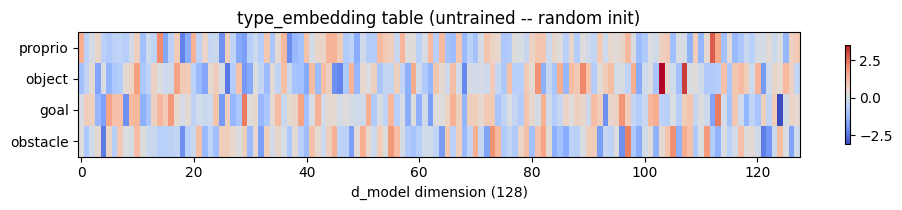

In [15]:

# The learned type-embedding table -- one row per entity kind. Random at
# init; training is what would shape these into something meaningful.
type_emb = tok.type_embedding.weight.detach().numpy()  # (num_types, d_model)
fig, ax = plt.subplots(figsize=(10, 2.2))
im = ax.imshow(type_emb, aspect="auto", cmap="coolwarm")
ax.set_yticks(range(len(entities.TYPE_ID)))
ax.set_yticklabels(list(entities.TYPE_ID.keys()))
ax.set_xlabel("d_model dimension (128)")
ax.set_title("type_embedding table (untrained -- random init)")
plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout(); plt.show()



## 11. The model: `ActionChunkTransformer`

1. `EntityTokenizer` builds the tagged token set (section 10).
2. A single learned **context token** (same idea as BERT's `[CLS]`) is
   prepended to the token set.
3. A `nn.TransformerEncoder` lets every token attend to every other token
   (self-attention) -- padded obstacle slots are excluded via the mask, so
   they can never influence the result. This is where the model learns
   things like "the next gripper move depends on both the arm's current
   bend and the cube's relative position", without us hand-coding that
   relationship.
4. The context token's final vector is fed through a small MLP that
   predicts the **entire** action chunk in one shot.


In [16]:

cfg = ModelConfig(d_model=128, nhead=4, num_layers=3, dim_feedforward=256, chunk_size=12, action_dim=10)
model = ActionChunkTransformer(cfg)

param_rows = [(name, sum(p.numel() for p in module.parameters()))
              for name, module in [("tokenizer", model.tokenizer),
                                    ("context_token", torch.nn.ParameterList([model.context_token])),
                                    ("transformer encoder", model.encoder),
                                    ("action head", model.action_head)]]
param_table = pd.DataFrame(param_rows, columns=["component", "n_parameters"])
param_table.loc[len(param_table)] = ["TOTAL", sum(p.numel() for p in model.parameters())]
param_table


,component,n_parameters
0,tokenizer,5120
1,context_token,128
2,transformer encoder,397440
3,action head,63864
4,TOTAL,466552


In [17]:

# one forward pass, untrained, just to confirm the shapes flow through end to end
with torch.no_grad():
    pred = model(batch["proprio"][:, -1], batch["object"][:, -1], batch["goal"][:, -1],
                 batch["obstacles"][:, -1], batch["obstacle_mask"][:, -1])
print("predicted action chunk shape:", tuple(pred.shape), " <- (batch, chunk_size, action_dim)")


predicted action chunk shape: (8, 12, 10)  <- (batch, chunk_size, action_dim)



## 12. Training loop

Everything above was setup and explanation. This is the actual training:

- Split the 298 episodes into train/validation **by episode** (not by
  individual timestep) so validation samples come from episodes the model
  never trained on.
- Standard supervised loop: predict a chunk, compare to the recorded
  pseudo-actions with `masked_mse_loss`, backprop, step the optimizer.
- Track train and validation loss per epoch and plot the curve.

No simulator involved anywhere in this section -- purely arithmetic over
the recorded CSV data.


In [18]:

import glob, random

all_files = sorted(glob.glob(os.path.join(DATA_DIR, "*.csv")))
random.Random(0).shuffle(all_files)
n_val = 30
val_files = sorted(all_files[:n_val])
train_files = sorted(all_files[n_val:])
print(f"train episodes: {len(train_files)}   val episodes: {len(val_files)}")

# EpisodeChunkDataset globs a whole directory by design (see dataset.py) --
# for an episode-level train/val split we just build the same object by
# hand from an explicit file list, reusing all of its internal logic.
from src.episode import load_episode as _load_episode
from src.dataset import EpisodeChunkDataset as _Base

def make_dataset(files, **kwargs):
    ds = _Base.__new__(_Base)
    ds.chunk_size = kwargs.get("chunk_size", 12)
    ds.history = kwargs.get("history", 0)
    ds.max_obstacles = kwargs.get("max_obstacles", 8)
    ds.action_mode = kwargs.get("action_mode", "next_state")
    ds.episodes = [_load_episode(f, action_mode=ds.action_mode) for f in files]
    entities.validate_feature_dims(ds.episodes[0])
    ds.index = []
    for ep_idx, e in enumerate(ds.episodes):
        n_actions = len(e.action_base_yaw_rate)
        for start in range(n_actions):
            ds.index.append((ep_idx, start))
    return ds

train_ds = make_dataset(train_files, chunk_size=12, history=0, max_obstacles=8, action_mode="next_state")
val_ds = make_dataset(val_files, chunk_size=12, history=0, max_obstacles=8, action_mode="next_state")
print(f"train samples: {len(train_ds)}   val samples: {len(val_ds)}")


train episodes: 268   val episodes: 30


train samples: 14316   val samples: 1603


In [19]:

train_dl = DataLoader(train_ds, batch_size=64, shuffle=True)
val_dl = DataLoader(val_ds, batch_size=64, shuffle=False)

model = ActionChunkTransformer(ModelConfig(d_model=128, nhead=4, num_layers=3,
                                            dim_feedforward=256, chunk_size=12, action_dim=10))
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

def run_epoch(dl, train: bool):
    model.train(train)
    total_loss, total_n = 0.0, 0
    for batch in dl:
        pred = model(batch["proprio"][:, -1], batch["object"][:, -1], batch["goal"][:, -1],
                     batch["obstacles"][:, -1], batch["obstacle_mask"][:, -1])
        loss = masked_mse_loss(pred, batch["action_chunk"], batch["action_mask"])
        if train:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        total_loss += loss.item() * len(batch["step"])
        total_n += len(batch["step"])
    return total_loss / total_n

N_EPOCHS = 15
history = {"train": [], "val": []}
for epoch in range(N_EPOCHS):
    train_loss = run_epoch(train_dl, train=True)
    with torch.no_grad():
        val_loss = run_epoch(val_dl, train=False)
    history["train"].append(train_loss)
    history["val"].append(val_loss)
    print(f"epoch {epoch+1:2d}/{N_EPOCHS}  train_loss={train_loss:.4f}  val_loss={val_loss:.4f}")


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:529: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


epoch  1/15  train_loss=0.0076  val_loss=0.0010


epoch  2/15  train_loss=0.0013  val_loss=0.0007


epoch  3/15  train_loss=0.0010  val_loss=0.0007


epoch  4/15  train_loss=0.0008  val_loss=0.0005


...

epoch 11/15  train_loss=0.0005  val_loss=0.0005


epoch 12/15  train_loss=0.0005  val_loss=0.0005


epoch 13/15  train_loss=0.0005  val_loss=0.0004


epoch 14/15  train_loss=0.0005  val_loss=0.0004


epoch 15/15  train_loss=0.0005  val_loss=0.0004


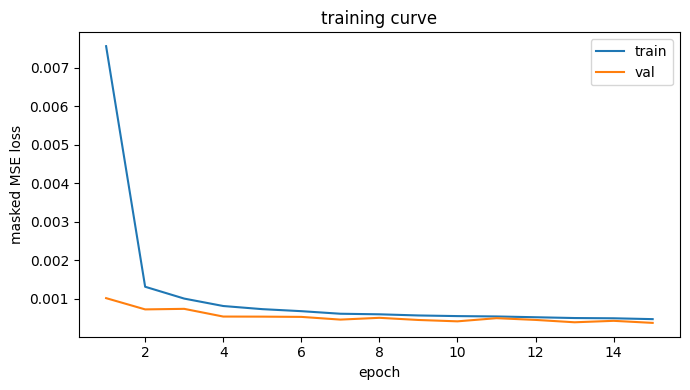

In [20]:

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1, N_EPOCHS + 1), history["train"], label="train")
ax.plot(range(1, N_EPOCHS + 1), history["val"], label="val")
ax.set_xlabel("epoch"); ax.set_ylabel("masked MSE loss")
ax.set_title("training curve")
ax.legend()
plt.tight_layout(); plt.show()


In [21]:

os.makedirs("checkpoints", exist_ok=True)
ckpt_path = os.path.join("checkpoints", "action_chunk_transformer.pt")
torch.save({"model_state_dict": model.state_dict(), "config": model.cfg.__dict__}, ckpt_path)
print(f"saved checkpoint to {ckpt_path}")
print("(checkpoints/ is gitignored -- retrain locally to reproduce, or commit this file explicitly if you want to keep it)")


saved checkpoint to checkpoints/action_chunk_transformer.pt
(checkpoints/ is gitignored -- retrain locally to reproduce, or commit this file explicitly if you want to keep it)



## Where this leaves us

We now have a trained (if only lightly -- 15 epochs, a first pass) model
that maps entity tokens to a predicted action chunk, with train/val loss
both trending down. What's deliberately **not** in this notebook: loading
this checkpoint back and actually running it against the simulator, step by
step, to see whether it can complete the task on held-out cube/target
positions. That's real inference/evaluation, and it gets its own notebook.
